<h2>3.1 Grundlagen historischer Finanzdaten</h2>
<h3>3.1.1 Indexfonds und ETFs</h3>
<p>Ein Index bildet die Wertentwicklung eines festgelegten Marktbereichs als rechnerische Kennzahl ab. Der S&P 500 umfasst beispielsweise die 500 grössten Unternehmen der USA. Weil sich ein marktbreiter Index auf zahlreiche Titel stützt, hängt seine Entwicklung nicht von einem einzelnen Unternehmen ab. Ein Indexfonds versucht, seinen Referenzindex möglichst genau nachzubilden, anstatt ihn zu übertreffen [@kommerLeichteEinstiegWelt2025, S. 464-465].<br>Welche Wertpapiere im Index enthalten sind und wie stark sie gewichtet werden, bestimmt dessen Regelwerk. Es regelt ebenfalls, unter welchen Voraussetzungen Titel hinzukommen oder entfernt werden. Die Zusammensetzung wird üblicherweise in einem festen Rhythmus, etwa halb- oder vierteljährlich, überprüft [@kommerLeichteEinstiegWelt2025, S. 465].</p>
<p>Bei einem ETF werden Fondsanteile während der Börsenzeiten an einem Handelsplatz gehandelt. Der Zugang kann über eine Bank oder einen Broker erfolgen; ausgeführt wird der Kauf an der Börse. Kommer zählt Indexfonds und ETFs zu den bedeutendsten Finanzinnovationen seit 1971 [@kommerLeichteEinstiegWelt2025, S. 58]. Für Privatanleger sind sie unter anderem interessant, weil ihr Aufbau vergleichsweise leicht nachvollziehbar ist, die Zusammensetzung offengelegt wird und die Verwaltung mit wenig eigenem Aufwand verbunden ist. Hinzu kommen in der Regel geringe Gebühren. Ihre Konstruktion beruht zudem auf Erkenntnissen der Kapitalmarktforschung [@kommerLeichteEinstiegWelt2025, S. 59-60].</p>
<h3>3.1.2 Eignung für die Untersuchung</h3>
<p>Marktbreite ETFs sind für meine Untersuchung gut geeignet, da sie ganze Anlageklassen mit geringem Aufwand abbilden. ETFs sind günstig, bequem und transparent. Für meine Untersuchung ist der Total Return besser geeignet als der Kursindex. Der Kursindex berücksichtigt keine Dividenden, die wichtig sind, um die wahre Performance nachzuweisen.</p>
<h2>3.2 Historische Finanzdaten und Zeitreihen</h2>
<h3>3.2.1 Zeitreihen</h3>
<p>Historische Finanzdaten bilden die Grundlage für den Vergleich der Anlagestrategien. Eine finanzielle Zeitreihe entsteht, wenn der Kurs eines Indexfonds über einen längeren Zeitraum erfasst wird. Die Zeitreihe besteht also aus Beobachtungen, die einem bestimmten Datum zugeordnet werden. Wichtig ist dabei die Reihenfolge, denn sie zeigt die Veränderung von einer Beobachtung zur nächsten. Für diese Zeitreihen wird pandas in Python sehr wichtig sein. Wes McKinney, der Hauptautor von pandas, arbeitete als Analyst bei AQR Capital Management, als er mit der Entwicklung der Library begann. Man kann also sicher sagen, dass pandas darauf ausgelegt ist, mit Finanzdaten zu arbeiten [@hilpischPythonFinanceMastering2019, S. 304].
<h3>3.2.2 Frequenzen</h3>
Zeitreihen können ausserdem in verschiedenen Frequenzen vorliegen: täglich, wöchentlich, monatlich und jährlich. Diese Frequenzen werden für meine Arbeit relevant sein. Da meine Untersuchung langfristig angesetzt ist, sind kleinere Beobachtungsintervalle beziehungsweise kleinere "Timeframes", auf Deutsch Zeitrahmen, nicht von Bedeutung.</p>

| Alias | Description |
|:---|:---|
| `B` | Business day frequency |
| `C` | Custom business day frequency (experimental) |
| `D` | Calendar day frequency |
| `W` | Weekly frequency |
| `M` | Month end frequency |
| `BM` | Business month end frequency |
| `MS` | Month start frequency |
| `BMS` | Business month start frequency |
| `Q` | Quarter end frequency |
| `BQ` | Business quarter end frequency |
| `QS` | Quarter start frequency |
| `BQS` | Business quarter start frequency |
| `A` | Year end frequency |
| `BA` | Business year end frequency |
| `AS` | Year start frequency |
| `BAS` | Business year start frequency |
| `H` | Hourly frequency |
| `T` | Minutely frequency |
| `S` | Secondly frequency |
| `L` | Milliseconds |
| `U` | Microseconds |

<p>Ausführliche Liste mit Beispielfrequenzen [@hilpischPythonFinanceMastering2019, S. 191-192].</p>
<h3>3.2.3 Resampling</h3>
<p>Wenn ein Datensatz nicht im gewünschten Zeitrahmen vorliegt, kann man ihn mithilfe des "Resamplings" umwandeln. Normalerweise geschieht das von einem kleineren Zeitrahmen zu einem grösseren. Das nennt man "Downsampling". Es wird später vor allem wichtig sein, um die Daten in ein einheitliches Format zu bringen und sie vergleichen zu können.</p>

<code><pre>result = df.resample(frequenz).agg(aggregation)</pre></code>

<p>Für das "Resampling" gibt es in pandas eine eingebaute Funktion, die oben stark vereinfacht dargestellt ist. Nun folgt ein konkretes Beispiel für die Nutzung dieser Funktion.</p>

In [ ]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion resample_dataframe() nimmt ein DataFrame, eine Frequenz und eine Aggregationsmethode als Eingabe und gibt ein resampletes DataFrame zurück
def resample_dataframe(df: pd.DataFrame, frequenz: str, aggregation: dict):
    return df.resample(frequenz).agg(aggregation)

# Beispiel zur Nutzung der Funktion
df = pd.DataFrame({
    "Datum": ["2026-07-27", "2026-07-28", "2026-07-29", "2026-07-30", "2026-07-31", "2026-08-01", "2026-08-02", "2026-08-03", "2026-08-04", "2026-08-05", "2026-08-06", "2026-08-07", "2026-08-08", "2026-08-09"],
    "Kurs": [101, 104, 105, 106, 108, 107, 110, 112, 111, 115, 116, 118, 117, 120]
})

# Konvertiert die Spalte "Datum" in das Datetime-Format, um Zeitreihenoperationen zu ermöglichen.
df["Datum"] = pd.to_datetime(df["Datum"])
# Setzt die Spalte "Datum" als Index des DataFrames
df = df.set_index("Datum")

weekly = resample_dataframe(
    df,
    "W", # Resampling-Frequenz: "W" steht für wöchentlich
    {"Kurs": "last"} # Aggregationsmethode: "last" bedeutet, dass der letzte Kurswert jeder Woche genommen wird
)

print(f"Wöchentliche Kurse:\n{weekly}")

Wöchentliche Kurse:
            Kurs
Datum           
2026-08-02   110
2026-08-09   120


Quelle zur Nutzung von to_datetime() [@mckinneyPythonDataAnalysis2022, S. 511].

<p>Um Vorausschauverzerrung zu vermeiden, sollte man grundsätzlich immer den letzten verfügbaren Wert des Intervalls verwenden.</p>

<h2>3.3 Rendite</h2>

<h3>3.3.1 Einfache Rendite</h3>
<p>Hilpisch unterscheidet absolute Veränderungen und prozentuale Veränderungen beziehungsweise einfache Renditen [@hilpischPythonFinanceMastering2019, S. 315-316].</p>
<b>Absolute Änderung:</b>
$$
\Delta P_t=P_t-P_{t-1}
$$
<b>Einfache Rendite:</b>
$$
r_t=\frac{P_t}{P_{t-1}}-1
$$
<p>Quelle der Formeln und der entsprechenden Pandas-Umsetzung: [@hilpischPythonFinanceMastering2019, S. 315-316; @PandasSeriespct_changePandas305].</p>

In [49]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion absolute_aenderung() berechnet die absolute Änderung der Werte in einer Pandas-Series
def absolute_aenderung(df: pd.Series):
    # df.diff() berechnet den absoluten Unterschied zum vorherigen Wert
    return df.diff()

# Die Funktion prozentuale_aenderung() berechnet die prozentuale Änderung der Werte in einer Pandas-Series
def prozentuale_aenderung(df: pd.Series):
    # df.pct_change() berechnet die prozentuale Änderung zum vorherigen Wert
    return df.pct_change()

# Beispiel zur Nutzung der Funktionen
df = pd.Series([100, 110, 126.5])

aenderung_absolut = absolute_aenderung(df)

aenderung_prozentuale = prozentuale_aenderung(df)

# Der erste Wert ist NaN, weil es keinen vorherigen Wert gibt
print(f"Absolute Änderung:\n{aenderung_absolut}")

# Die prozentuale Änderung wird als Dezimalzahl dargestellt. Für Prozent mit 100 multiplizieren
print(f"Prozentuale Änderung:\n{aenderung_prozentuale * 100}")

Absolute Änderung:
0     NaN
1    10.0
2    16.5
dtype: float64
Prozentuale Änderung:
0     NaN
1    10.0
2    15.0
dtype: float64


<h3>3.3.2 Logarithmische Rendite und kumulierte Rendite</h3>
<p>Logarithmische Renditen lassen sich über die Zeit addieren. Durch die Exponentialfunktion erhält man aus ihrer Summe wieder den Wachstumsfaktor [@hilpischPythonFinanceMastering2019, S. 317-318].</p>
<b>Logarithmische Rendite:</b>
$$
\ell_t=\ln\left(\frac{P_t}{P_{t-1}}\right)
$$
<b>Kumulierte logarithmische Rendite und Wachstumsfaktor:</b>
$$
L_t=\sum_{i=1}^{t}\ell_i,\qquad G_t=e^{L_t}
$$
<p>Quelle der Formeln: [@hilpischPythonFinanceMastering2019, S. 317-318].</p>

In [50]:
# Importiert die Numpy-Bibliothek
import numpy as np
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion kumulierte_rendite() berechnet die kumulierte logarithmische Rendite
def kumulierte_rendite(preise: pd.Series):
    # np.log() berechnet den natürlichen Logarithmus
    # und shift(1) verschiebt die Serie um einen Tag zurück, um die Rendite zu berechnen
    log_rendite = np.log(preise / preise.shift(1))
    # cumsum() summiert die logarithmischen Renditen über die Zeit
    kumulierte_log_rendite = log_rendite.cumsum()
    return kumulierte_log_rendite

# Die Funktion wachstumsfaktor() berechnet den Gesamtwachstumsfaktor aus der kumulierten logarithmischen Rendite
def wachstumsfaktor(preise: pd.Series):
    kumulierte_log_rendite = kumulierte_rendite(preise)
    # np.exp() macht den Logarithmus rückgängig und zeigt den Gesamtwachstumsfaktor
    wachstumsfaktoren = np.exp(kumulierte_log_rendite)
    return wachstumsfaktoren


# Beispiel zur Nutzung der Funktionen
df = pd.Series([100, 110, 126.5])

print(f"Kumulierte logarithmische Rendite:\n{kumulierte_rendite(df)}\n")
print(f"Wachstumsfaktor:\n{wachstumsfaktor(df)}")

Kumulierte logarithmische Rendite:
0         NaN
1    0.095310
2    0.235072
dtype: float64

Wachstumsfaktor:
0      NaN
1    1.100
2    1.265
dtype: float64


<h3>3.3.3 Geometrische Rendite</h3>
<p>Die geometrische Rendite beschreibt das tatsächlich realisierte durchschnittliche Wachstum pro Periode über mehrere Zeiträume hinweg. Der arithmetische Durchschnitt ist der normale mathematische Mittelwert. Dieser wird zum Beispiel auch bei der Sharpe Ratio genutzt [@phamPerformance60402025, S. 50-51]. Eine Form der geometrischen Rendite ist die annualisierte Rendite. Dabei wird die Rendite auf ein Jahr normiert.</p>

<b>Geometrischer Mittelwert (Formel):</b>
$$
\operatorname{Mean}(R)
=
\sqrt[N]{\prod_{i=1}^{N} R_i}
$$
<p>Dabei bezeichnet <b>Mean(R)</b> den geometrischen Mittelwert, <b>N</b> die Anzahl der Perioden, <b>R<sub>i</sub></b> den Renditefaktor einer einzelnen Periode, <b>∏</b> das Produkt aller Renditefaktoren und <b><sup>N</sup>√</b> die <i>N</i>-te Wurzel [@phamPerformance60402025, S. 51].</p>
<b>Annualisierte Rendite bei <i>m</i> Perioden pro Jahr:</b>
$$
r_{\mathrm{ann}}=\operatorname{Mean}(R)^m-1
$$
<p>Die Annualisierungsformel ist die direkte Umrechnung des zuvor definierten geometrischen Periodenmittels auf <i>m</i> Perioden pro Jahr.</p>


In [51]:
# Importiert die Numpy-Bibliothek
import numpy as np

# Die Funktion geometrisches_mittel() berechnet das geometrische Mittel einer Liste von Werten
def geometrisches_mittel(werte: np.ndarray):
    # np.log() berechnet den natürlichen Logarithmus jedes Wertes,
    # np.mean() berechnet den Durchschnitt der Logarithmen
    # und np.exp() macht den Logarithmus rückgängig
    return np.exp(np.mean(np.log(werte)))

# Beispiel zur Nutzung der Funktion
werte = np.array([1.1, 1.2, 0.9, 1.05])
print(f"Geometrisches Mittel: {geometrisches_mittel(werte)}")

Geometrisches Mittel: 1.0568210009926833


In [52]:
# Die Funktion annualisierte_rendite() berechnet die annualisierte Rendite aus einer Liste von Werten und der Anzahl der Perioden pro Jahr
def annualisierte_rendite(werte: np.ndarray, perioden_pro_jahr: int):
    return geometrisches_mittel(werte) ** perioden_pro_jahr - 1

# Beispiel zur Nutzung der Funktion
werte = np.array([1.1, 1.2, 0.9, 1.05])
perioden_pro_jahr = 12  # zum Beispiel monatliche Renditen
print(f"Annualisierte Rendite: {annualisierte_rendite(werte, perioden_pro_jahr)}")

Annualisierte Rendite: 0.9409628324239998


<h3>3.3.4 Nominal und real</h3>
<p>Die reale Rendite ist die inflationsbereinigte Rendite. Vor allem über längere Zeiträume ist es sehr wichtig, das zu berücksichtigen. Aus der Grafik des Bundesamts für Statistik kann man für die letzten 10 Jahre eine durchschnittliche Inflation von 0.8% in der Schweiz ablesen [@Preise]. Das heisst, ein Investment muss jährlich mindestens 0.8% erzielen, damit die Kaufkraft erhalten bleibt.</p>

<h2>3.4 Volatilität</h2>
<h3>3.4.1 Bedeutung der Volatilität</h3>
<p>Zwei Anlagestrategien können die gleiche Rendite erzielen, aber unterschiedlich stark schwanken. Die Volatilität beschreibt die Stärke dieser Schwankungen. Je höher die Volatilität ist, desto höher wird das Schwankungsrisiko eingeschätzt. Kommer bezeichnet die Volatilität als das verbreitetste Risikomass der Finanzökonomie. Ausserdem erklärt er, dass die Begriffe Volatilität und Standardabweichung im Anlagekontext häufig gleichbedeutend verwendet werden [@kommerSouveraenInvestierenMit2025, S. 143–144]. Da die Volatilität in die Berechnung der Sharpe Ratio einfliesst, beeinflusst sie auch die Beurteilung einer Rendite im Verhältnis zum übernommenen Risiko.</p>

<h3>3.4.2 Berechnung der Volatilität</h3>
<p>Die historische Volatilität wird anhand der Standardabweichung der periodischen Renditen bestimmt. Dazu wird zuerst der arithmetische Mittelwert der betrachteten Renditen berechnet. Anschliessend wird untersucht, wie stark die Rendite jeder einzelnen Periode von diesem Durchschnitt abweicht. Die Standardabweichung fasst diese Abweichungen in einer Kennzahl zusammen [@kommerSouveraenInvestierenMit2025, S. 144].</p>

<b>Formel für die Standardabweichung:</b>
$$
\sigma = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(r_i-\bar{r})^2}
$$
<p>Die Formel entspricht der im Code verwendeten Stichproben-Standardabweichung mit <code>ddof=1</code> [@PandasSeriesstdPandas305]. Kommer erläutert Bedeutung und Interpretation der Standardabweichung im Anlagekontext [@kommerSouveraenInvestierenMit2025, S. 144].</p>

<p>Dabei bezeichnet <b>σ</b> die Standardabweichung, <b>n</b> die Anzahl der Renditen, <b>r<sub>i</sub></b> die Rendite einer einzelnen Periode und <b>r̄</b> den arithmetischen Mittelwert aller Renditen. Die Abweichungen vom Mittelwert werden quadriert. Deshalb fliessen sowohl negative als auch positive Abweichungen in die Berechnung ein [@kommerSouveraenInvestierenMit2025, S. 144].</p>
<p>Wichtig ist, dass man prozentuale Renditen und nicht absolute Kursänderungen verwendet. Sonst kann man verschiedene Kurse nicht miteinander vergleichen.</p>

In [53]:
# Importiert die Numpy-Bibliothek
import numpy as np
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion standardabweichung() berechnet die Standardabweichung einer Liste von Werten
def standardabweichung(werte: np.ndarray):
    # Werte in eine Pandas-Series umwandeln
    werte = pd.Series(werte, dtype="float64")

    # Standardabweichung mithilfe der Pandas-Funktion .std() berechnen
    return werte.std(ddof=1)


# Beispiel zur Nutzung der Funktion
werte = np.array([1.1, 1.2, 0.9, 1.05])
print(f"Standardabweichung: {standardabweichung(werte)}")

Standardabweichung: 0.12499999999999997


<h3>3.4.3 Annualisierung</h3>
<p>Die berechnete Standardabweichung bezieht sich zunächst auf die verwendete Frequenz. Wählt man beispielsweise für einen Zeitraum von einem Monat eine Periodenlänge von einem Tag, erhält man eine tägliche Volatilität. Damit man verschiedene Datensätze vergleichen kann, rechnet man sie normalerweise auf ein Jahr hoch. Das nennt man Annualisierung.</p>
<b>Formel zur Berechnung der annualisierten Volatilität:</b>

$$
\sigma_{\mathrm{ann}} = \sigma_{\mathrm{Periode}}\sqrt{m}
$$
<p>Quelle der Formel: [@hilpischPythonFinanceMastering2019, S. 694].</p>
<p>Dabei bezeichnet <b>m</b> die Anzahl der betrachteten Perioden pro Jahr. Die tägliche Standardabweichung <b>σ<sub>Periode</sub></b> wird deshalb mit der Quadratwurzel aus <b>m</b> multipliziert. Bei täglichen Börsendaten wird häufig mit 252 Handelstagen gerechnet. Daraus resultiert die annualisierte Volatilität <b>σ<sub>ann</sub></b> [@hilpischPythonFinanceMastering2019, S. 694]. Die Quadratwurzel-Skalierung setzt insbesondere voraus, dass die periodischen Renditen nicht seriell korreliert sind [@sharpeSharpeRatioFall2021].</p>

In [54]:
# Importiert die Numpy-Bibliothek
import numpy as np

# Die Funktion annualisierte_volatilitaet() berechnet die annualisierte Volatilität aus einer Liste von Werten und der Anzahl der Perioden pro Jahr
def annualisierte_volatilitaet(werte: np.ndarray, perioden_pro_jahr: int):
    # Die Standardabweichung der Werte wird mit der Quadratwurzel der Anzahl der Perioden pro Jahr multipliziert
    annualisierte_volatilitaet = standardabweichung(werte) * perioden_pro_jahr ** (1/2)
    return annualisierte_volatilitaet

# Beispiel zur Nutzung der Funktion
werte = np.array([1.1, 1.2, 0.9, 1.05])
perioden_pro_jahr = 12  # zum Beispiel monatliche Renditen
print(f"Annualisierte Volatilität: {annualisierte_volatilitaet(werte, perioden_pro_jahr)}")

Annualisierte Volatilität: 0.4330127018922192


<h3>3.4.4 Interpretation</h3>
<p>Eine tiefe Volatilität bedeutet, dass die periodischen Renditen nahe bei ihrem Mittelwert liegen. Die Wertentwicklung verläuft somit vergleichsweise gleichmässig. Eine hohe Volatilität zeigt dagegen, dass es stärkere positive und negative Ausschläge gab. Eine hohe Volatilität bedeutet nicht automatisch, dass eine Anlage eine schlechte Rendite erzielt. Es deutet jedoch darauf hin, dass der Preis während dieser Zeit stärkere Schwankungen durchgemacht hat [@kommerSouveraenInvestierenMit2025, S. 147-149].</p>

<h3>3.4.5 Diversifikation</h3>
<p>Diversifikation kann die Volatilität eines Gesamtportfolios senken. Bei Marktschwankungen können sich zwei Kurse gegenseitig ausgleichen. Ein breit diversifiziertes Portfolio zeigt meist eine tiefere Volatilität, sofern die Renditen der Wertpapiere nicht untereinander zusammenhängen [@kommerSouveraenInvestierenMit2025, S. 148].</p>
<p>Die Volatilität kennt jedoch auch Grenzen. Da sowohl positive als auch negative Ausschläge gemessen werden, wird nicht zwischen unerwünschten Verlusten und erwünschten Gewinnen unterschieden. Ausserdem sagt sie nichts über die Stärke der Verluste und die Länge der Verlustphase aus. Sie misst nur einen Risikotyp und deckt nicht das ganze Risikospektrum ab. Deswegen kann man die Volatilität nicht als einzigen Faktor nutzen, um das Gesamtrisiko zu beurteilen [@kommerSouveraenInvestierenMit2025, S. 151].</p>

<h3>3.4.6 Beispiel</h3>

Strategie A
Durchschnittliche Monatsrendite: 1.00%
Annualisierte Volatilität: 0.82%

Strategie B
Durchschnittliche Monatsrendite: 1.00%
Annualisierte Volatilität: 14.09%


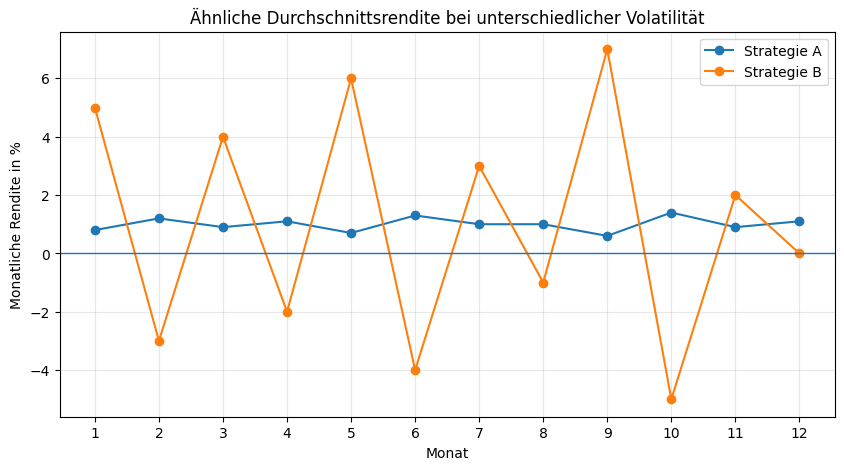

In [57]:
# Importiert die Numpy-Bibliothek
import numpy as np
# Importiert die Pandas-Bibliothek
import pandas as pd
# Importiert die Matplotlib-Bibliothek für die Visualisierung
import matplotlib.pyplot as plt


# Monatliche Renditen der weniger volatilen Strategie
strategie_a = pd.Series([0.008, 0.012, 0.009, 0.011, 0.007, 0.013, 0.010, 0.010, 0.006, 0.014, 0.009, 0.011])


# Monatliche Renditen der volatilen Strategie
strategie_b = pd.Series([0.05, -0.03, 0.04, -0.02, 0.06, -0.04, 0.03, -0.01, 0.07, -0.05, 0.02, 0.00])


# Durchschnittliche Monatsrenditen berechnen
mittelwert_a = strategie_a.mean()
mittelwert_b = strategie_b.mean()


# Annualisierte Volatilitäten berechnen
volatilitaet_a = annualisierte_volatilitaet(strategie_a, 12)
volatilitaet_b = annualisierte_volatilitaet(strategie_b, 12)


# Ergebnisse ausgeben
print("Strategie A")
print(f"Durchschnittliche Monatsrendite: {mittelwert_a:.2%}")
print(f"Annualisierte Volatilität: {volatilitaet_a:.2%}")

print()

print("Strategie B")
print(f"Durchschnittliche Monatsrendite: {mittelwert_b:.2%}")
print(f"Annualisierte Volatilität: {volatilitaet_b:.2%}")


# Monatsnummern für die Abbildung
monate = range(1, 13)


# Renditen als Prozentwerte darstellen
plt.figure(figsize=(10, 5))

plt.plot(
    monate,
    strategie_a * 100,
    marker="o",
    label="Strategie A"
)

plt.plot(
    monate,
    strategie_b * 100,
    marker="o",
    label="Strategie B"
)

# Linie bei null Prozent
plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Monat")
plt.ylabel("Monatliche Rendite in %")
plt.title(
    "Ähnliche Durchschnittsrendite bei unterschiedlicher Volatilität"
)

plt.xticks(monate)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<p>Das Beispiel zeigt übertrieben, wie ein Kurs bei gleicher Rendite eine ganz unterschiedliche Volatilität aufweisen kann.</p>

<h2>3.5 Drawdown</h2>

<h3>3.5.1 Bedeutung des Drawdowns</h3>
<p>Die Volatilität misst die allgemeine Streuung der Renditen, zeigt aber nicht direkt, wie tief eine Anlage während einer Verlustphase unter ihren bisherigen Höchststand fällt. Ein Drawdown vergleicht deshalb den aktuellen Vermögenswert mit dem höchsten Wert, der bis zu diesem Zeitpunkt erreicht wurde. An einem neuen Höchststand beträgt der Drawdown 0%. Liegt der Vermögenswert unter dem bisherigen Höchststand, ist der Drawdown negativ [@kommerSouveraenInvestierenMit2025, S. 151-152].</p>
<p>Der Maximum Drawdown ist der grösste kumulierte historische Verlust innerhalb des untersuchten Zeitraums. Er zeigt den schlechtesten beobachteten Rückgang von einem früheren Höchststand bis zum darauffolgenden Tiefststand [@kommerSouveraenInvestierenMit2025, S. 151-153].</p>

<h3>3.5.2 Berechnung</h3>
<b>Formel für den laufenden Drawdown:</b>

$$
DD_t = \frac{V_t}{\max(V_0,\ldots,V_t)}-1
$$
<p>Quelle der relativen Drawdown-Formel: [@phamPerformance60402025, S. 51].</p>

<p>Dabei bezeichnet <b>V<sub>t</sub></b> den Vermögenswert zum Zeitpunkt <b>t</b>. Im Nenner steht der höchste Vermögenswert, der bis zu diesem Zeitpunkt beobachtet wurde. <b>DD<sub>t</sub></b> steht für den Drawdown zum Zeitpunkt t. Der Maximum Drawdown ist der kleinste und somit stärkste negative Wert der gesamten Drawdown-Reihe [@phamPerformance60402025, S. 51].</p>
<b>Formel für den Maximum Drawdown:</b>

$$
MDD = \min_t(DD_t)
$$
<p>Quelle der Formel: [@phamPerformance60402025, S. 51].</p>

In [ ]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion drawdown() berechnet den laufenden Drawdown aus periodischen Renditen
def drawdown(renditen: pd.Series):
    # Aus den Renditen wird zunächst mit + 1 der Wachstumsfaktor gebildet
    # Anschliessend werden mit .cumprod() alle Renditen nacheinander multipliziert, damit man den Zinseszinseffekt erhält
    vermoegen = (1 + renditen).cumprod()
    # cummax() bestimmt den bis dahin höchsten Vermögenswert
    bisheriger_hoechststand = vermoegen.cummax()
    # vermoegen / bisheriger_hoechststand berechnet den Wachstumsfaktor im Verhältnis zum höchsten Vermögenswert
    # Durch - 1 erhält man den prozentualen Unterschied zum höchsten Vermögenswert als Dezimalzahl
    return vermoegen / bisheriger_hoechststand - 1

# Die Funktion maximum_drawdown() gibt den tiefsten Wert der Drawdown-Reihe zurück
def maximum_drawdown(renditen: pd.Series):
    return drawdown(renditen).min()

# Beispiel zur Nutzung der Funktionen
beispiel_renditen = pd.Series([0.10, -0.05, -0.20, 0.08, 0.15, 0.04])

print(f"Drawdown-Reihe:\n{drawdown(beispiel_renditen)}\n")
print(f"Maximum Drawdown: {maximum_drawdown(beispiel_renditen):.2%}") # Von einer Dezimalzahl zu Prozent

Drawdown-Reihe:
0    0.000000
1   -0.050000
2   -0.240000
3   -0.179200
4   -0.056080
5   -0.018323
dtype: float64

Maximum Drawdown: -24.00%


<h3>3.5.3 Erholungsdauer und Grenzen</h3>
<p>Die Erholungsdauer beschreibt die Zeit vom früheren Höchststand, bis dieser Wert vollständig wieder erreicht wird. Die Verlusttiefe und die Verlustdauer sind zwei verschiedene Eigenschaften: Ein Drawdown kann tief, aber kurz oder weniger tief, aber sehr lang sein [@kommerSouveraenInvestierenMit2025, S. 163-164].</p>

<p>Für die Erholungsdauer und alle wichtigen Daten dazu nutzen wir zwei Funktionen aus QuantStats: <code>.to_drawdown_series()</code> und <code>.drawdown_details()</code> [@aroussiRanaroussiQuantstats2026].</p>

In [5]:
# Importiert die QuantStats-Bibliothek
import quantstats as qs
# Importiert die Pandas-Bibliothek
import pandas as pd

beispiel_renditen = pd.Series({
    "2024-01-31": 0.10,
    "2024-02-29": -0.05,
    "2024-03-31": -0.05,
    "2024-04-30": 0.12,
    "2024-05-31": 0.03,
    "2024-06-30": -0.10,
    "2024-07-31": 0.04,
    "2024-08-31": 0.08,
    "2024-09-30": -0.06,
    "2024-10-31": -0.04,
    "2024-11-30": 0.05,
    "2024-12-31": 0.03
})

drawdown_reihe = qs.stats.to_drawdown_series(beispiel_renditen)
erholungsphasen = qs.stats.drawdown_details(drawdown_reihe)
print(f"Drawdown-Reihe:\n{drawdown_reihe}\n")
print(f"Erholungsphasen:\n{erholungsphasen}\n")

Drawdown-Reihe:
2024-01-31    0.000000
2024-02-29   -0.050000
2024-03-31   -0.097500
2024-04-30    0.000000
2024-05-31    0.000000
2024-06-30   -0.100000
2024-07-31   -0.064000
2024-08-31    0.000000
2024-09-30   -0.060000
2024-10-31   -0.097600
2024-11-30   -0.052480
2024-12-31   -0.024054
dtype: float64

Erholungsphasen:
        start      valley         end  days  max drawdown  99% max drawdown
0  2024-02-29  2024-03-31  2024-03-31    32         -9.75              -5.0
1  2024-06-30  2024-06-30  2024-07-31    32        -10.00              -6.4
2  2024-09-30  2024-10-31  2024-12-31    93         -9.76              -6.0



<p>Der berechnete Maximum Drawdown hängt vom gewählten Zeitraum und von der Frequenz der Daten ab. Werden nur Jahresendwerte verwendet, können zwischenzeitliche Verluste übersehen und der tatsächliche Drawdown deutlich unterschätzt werden. Kommer empfiehlt deshalb einen langen Beobachtungszeitraum und weist auf die genauere Erfassung mit Monatsdaten hin. Der historische Maximum Drawdown beschreibt nur den schlimmsten Verlust in der untersuchten Stichprobe und stellt keine garantierte Verlustgrenze für die Zukunft dar [@kommerSouveraenInvestierenMit2025, S. 152-153].</p>

<h2>3.6 Sharpe Ratio</h2>
<h3>3.6.1 Bedeutung der Sharpe Ratio</h3>
<p>Die Rendite allein zeigt nicht, mit welchen Schwankungen ein Anlageergebnis erreicht wurde. Für einen risikobereinigten Vergleich wird deshalb zunächst die risikofreie Rendite von der Anlagenrendite abgezogen. Die Sharpe Ratio stellt den Durchschnitt dieser Überschussrenditen der Volatilität gegenüber [@kommerSouveraenInvestierenMit2025, S. 165-166].</p>
<p>Das Ergebnis lässt sich als historische Entschädigung für eine Einheit des gemessenen Schwankungsrisikos interpretieren. Unter ansonsten gleichen Berechnungsbedingungen weist ein höherer Wert auf ein vorteilhafteres Verhältnis zwischen Überschussrendite und Volatilität hin [@kommerSouveraenInvestierenMit2025, S. 166].</p>

<h3>3.6.2 Berechnung</h3>
<b>Formel für die annualisierte Sharpe Ratio:</b>

$$
SR_{\mathrm{ann}} = \frac{\overline{r-r_f}}{\sigma(r-r_f)}\sqrt{m}
$$
<p>Die periodische Sharpe Ratio ist bei Pham et al. angegeben [@phamPerformance60402025, S. 51]. Die Annualisierung mit der Quadratwurzel der Periodenzahl setzt insbesondere unkorrelierte periodische Überschussrenditen voraus [@sharpeSharpeRatioFall2021].</p>

<p>Dabei bezeichnet <b>r</b> die periodische Anlagenrendite, <b>r<sub>f</sub></b> die risikofreie Rendite derselben Periode, <b>σ(r-r<sub>f</sub>)</b> die Standardabweichung der periodischen Überschussrenditen und <b>m</b> die Anzahl der Perioden pro Jahr.</p>

In [6]:
# Importiert die Pandas-Bibliothek
import pandas as pd
# Importiert die QuantStats-Bibliothek
import quantstats as qs


# Die Funktion sharpe_ratio() berechnet die annualisierte Sharpe Ratio
def sharpe_ratio(renditen: pd.Series, risikofreie_renditen: pd.Series, perioden_pro_jahr: int):
    daten = pd.concat(
        [renditen, risikofreie_renditen],
        axis=1
    )

    daten.columns = ["Anlage", "Risikofrei"]

    # Berechnet die periodischen Überschussrenditen
    ueberschussrenditen = (
        daten["Anlage"]
        - daten["Risikofrei"]
    )

    # Berechnet und annualisiert die Sharpe Ratio mit QuantStats
    return qs.stats.sharpe(
        ueberschussrenditen,
        rf=0,
        periods=perioden_pro_jahr
    )


anlage = pd.Series([0.02, -0.01, 0.03, 0.01, -0.02, 0.025])

risikofrei = pd.Series([0.002, 0.002, 0.002, 0.002, 0.002, 0.002])

ergebnis = sharpe_ratio(
    anlage,
    risikofrei,
    perioden_pro_jahr=12
)

print(f"Annualisierte Sharpe Ratio: {ergebnis:.2f}")

Annualisierte Sharpe Ratio: 1.23


<h3>3.6.3 Interpretation und Grenzen</h3>
<p>Sharpe Ratios können nur sinnvoll verglichen werden, wenn Zeitraum, Datenfrequenz und Berechnungsweise identisch sind. Eine Sharpe Ratio für einen Zeitraum darf nicht direkt mit einer Kennzahl aus einem anderen Zeitraum verglichen werden [@kommerSouveraenInvestierenMit2025, S. 166].</p>
<p>Neben der vollständigen Variante existiert eine vereinfachte Raw Sharpe Ratio, bei welcher die risikofreie Rendite nicht abgezogen wird. Beide Varianten dürfen nicht vermischt werden [@kommerSouveraenInvestierenMit2025, S. 165-166]. Ausserdem bildet die Sharpe Ratio das Risiko nur über die Volatilität ab. Da die Volatilität nicht das gesamte Anlagerisiko beschreibt, werden Rendite und Drawdown in dieser Arbeit zusätzlich als getrennte Kennzahlen betrachtet [@kommerSouveraenInvestierenMit2025, S. 166].</p>

<h2>3.7 Diversifikation und Korrelation</h2>
<h3>3.7.1 Diversifikation</h3>
<p>Bei der Diversifikation wird das Kapital nicht auf eine einzelne Anlage konzentriert. Eine Streuung ist sowohl innerhalb derselben Anlageklasse, etwa über viele verschiedene Aktien, als auch zwischen Anlageklassen wie Aktien und Anleihen möglich [@kommerSouveraenInvestierenMit2025, S. 82].</p>
<p>Auf diese Weise lassen sich Risiken, die nur einzelne Unternehmen oder Branchen betreffen, erheblich verringern. Marktweite Kursschwankungen wirken dagegen auf viele Titel gleichzeitig und verschwinden auch in einem breit gestreuten Aktienportfolio nicht vollständig [@kommerSouveraenInvestierenMit2025, S. 85-86]. Für die Beurteilung ist deshalb entscheidend, wie die Bestandteile im Gesamtportfolio zusammenwirken [@kommerSouveraenInvestierenMit2025, S. 85].</p>

<h3>3.7.2 Korrelation</h3>
<p>Mit der Korrelation lässt sich untersuchen, wie eng die Renditen zweier Anlagen linear zusammenhängen. Ihr Koeffizient reicht von -1 bis +1: Am positiven Grenzwert bewegen sich beide Reihen vollständig in dieselbe Richtung, am negativen Grenzwert genau entgegengesetzt. Ein Wert von 0 zeigt, dass kein linearer Zusammenhang nachweisbar ist [@kommerSouveraenInvestierenMit2025, S. 82-83].</p>
<p>Ein Portfolio kann bereits von einer Korrelation unter +1 profitieren, da sich die Wertveränderungen seiner Bestandteile dann nicht vollkommen parallel entwickeln. Eine negative Korrelation ist somit keine Voraussetzung. Tendenziell nimmt die risikomindernde Wirkung der Kombination zu, wenn der Korrelationskoeffizient sinkt [@kommerSouveraenInvestierenMit2025, S. 82-83].</p>
<b>Formel für die Korrelation:</b>

$$
\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}
$$
<p>Dabei bezeichnet <b>ρ<sub>X,Y</sub></b> die Korrelation zwischen den Variablen <b>X</b> und <b>Y</b>, <b>Cov(X,Y)</b> ihre Kovarianz, <b>σ<sub>X</sub></b> die Standardabweichung von <b>X</b> und <b>σ<sub>Y</sub></b> die Standardabweichung von <b>Y</b> [@markowitzPortfolioSelection1952, S. 80].</p>
<b>Portfoliovarianz bei zwei Anlagen:</b>

$$
\sigma_p^2=w_1^2\sigma_1^2+w_2^2\sigma_2^2+2w_1w_2\sigma_1\sigma_2\rho_{1,2}
$$
<p>Dabei bezeichnet <b>σ<sub>p</sub><sup>2</sup></b> die Varianz des Portfolios, <b>w<sub>1</sub></b> und <b>w<sub>2</sub></b> die Gewichtungen der beiden Anlagen, <b>σ<sub>1</sub></b> und <b>σ<sub>2</sub></b> deren Standardabweichungen und <b>ρ<sub>1,2</sub></b> die Korrelation zwischen den Renditen der beiden Anlagen [@markowitzPortfolioSelection1952, S. 80-81; @phamPerformance60402025, S. 51].</p>

In [7]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion korrelationsmatrix() berechnet die Korrelationsmatrix der Renditen
def korrelationsmatrix(renditen: pd.DataFrame):
    # corr() berechnet die Korrelationsmatrix
    return renditen.corr()

# Beispiel zur Nutzung der Funktion
renditen = pd.DataFrame({
    "Aktien": [0.04, -0.03, 0.02, 0.05, -0.01, 0.03],
    "Anleihen": [0.01, 0.00, -0.01, 0.01, 0.02, 0.00],
    "ETF": [0.03, -0.02, 0.01, 0.04, 0.00, 0.02]
})

korrelation = korrelationsmatrix(renditen)
print(f"Korrelationsmatrix:\n{korrelation}\n")

Korrelationsmatrix:
                Aktien      Anleihen       ETF
Aktien    1.000000e+00  1.679908e-17  0.982953
Anleihen  1.679908e-17  1.000000e+00  0.176547
ETF       9.829533e-01  1.765470e-01  1.000000



In [5]:
# Importiert die Pandas-Bibliothek
import pandas as pd
# Importiert die Numpy-Bibliothek
import numpy as np

# Die Funktion portfolio_risiko() berechnet die Varianz und Volatilität eines Portfolios anhand der Renditen und Gewichte der einzelnen Anlagen
def portfolio_risiko(renditen, gewichte):
    cov = renditen.cov()
    varianz = gewichte @ cov @ gewichte
    volatilitaet = np.sqrt(varianz)
    return varianz, volatilitaet

# Beispiel zur Nutzung der Funktion
renditen = pd.DataFrame({
    "Aktien": [0.04, -0.03, 0.02, 0.05, -0.01, 0.03],
    "Anleihen": [0.01, 0.00, -0.01, 0.01, 0.02, 0.00],
    "ETF": [0.03, -0.02, 0.01, 0.04, 0.00, 0.02]
})
gewichte = pd.Series({"Aktien": 0.20, "Anleihen": 0.40, "ETF": 0.20})
var, vol = portfolio_risiko(renditen, gewichte)
print(f"Volatilität: {vol * 100:.2f}%")

Volatilität: 1.15%


<h3>3.7.3 Veränderliche Korrelationen</h3>
<p>Der Zusammenhang zwischen zwei Renditereihen kann sich im Zeitverlauf verändern. In Phasen fallender Börsenkurse bewegen sich risikobehaftete Anlagen zeitweise ähnlicher, sodass ihre Kombination ausgerechnet während einer Krise weniger stabilisierend wirken kann [@kommerSouveraenInvestierenMit2025, S. 84]. Historische Ländervergleiche zeigen ausserdem, dass Aktien und Anleihen langfristig nicht durchgehend negativ korrelierten und je nach untersuchtem Markt unterschiedliche Beziehungen aufwiesen [@phamPerformance60402025, S. 1-7].</p>

<h2>3.8 Asset-Allokation und Rebalancing</h2>
<h3>3.8.1 Asset-Allokation</h3>
<p>Anlagen mit vergleichbaren Rendite-, Risiko- und Liquiditätsmerkmalen werden zu einer Assetklasse zusammengefasst. Die Asset-Allokation legt fest, welche dieser Klassen ein Portfolio kombiniert und welchen Anteil jede davon am Gesamtvermögen erhält [@kommerSouveraenInvestierenMit2025, S. 169].</p>
<p>Die Portfoliorendite ergibt sich aus den einzelnen Renditebeiträgen, die jeweils mit dem zugehörigen Portfolioanteil gewichtet werden [@phamPerformance60402025, S. 50].</p>

$$
r_{p,t}=\sum_{k=1}^{N}w_{k,t}r_{k,t}
$$
<p>Dabei bezeichnet <b>w<sub>k,t</sub></b> das Gewicht und <b>r<sub>k,t</sub></b> die Rendite der Anlage <b>k</b> zum Zeitpunkt <b>t</b> [@phamPerformance60402025, S. 50].</p>

<h3>3.8.2 Gewichtungsdrift und Rebalancing</h3>
<p>Wenn sich die Bestandteile eines Portfolios unterschiedlich entwickeln, verändern sich ihre Gewichte automatisch. Eine Anlage mit einer höheren Rendite erhält danach einen grösseren Anteil am Gesamtportfolio. Kommer zeigt diese Gewichtungsdrift anhand eines Portfolios, dessen Zusammensetzung bereits nach einem Jahr von den festgelegten Zielgewichten abweicht [@kommerSouveraenInvestierenMit2025, S. 523].</p>

$$
w_{k,t+1}=\frac{w_{k,t}(1+r_{k,t})}{1+r_{p,t}}
$$
<p>Dabei bezeichnet <b>w<sub>k,t</sub></b> das Gewicht der Anlage <b>k</b> zu Beginn der Periode, <b>r<sub>k,t</sub></b> ihre Rendite, <b>r<sub>p,t</sub></b> die Rendite des Gesamtportfolios und <b>w<sub>k,t+1</sub></b> das daraus entstehende Gewicht am Ende der Periode.</p>
<p>Diese Formel ist eine eigene algebraische Darstellung der Gewichtungsdrift, die Kommer anhand eines Zahlenbeispiels zeigt [@kommerSouveraenInvestierenMit2025, S. 523-524].</p>
<p>Rebalancing stellt die ursprünglich festgelegten Zielgewichte wieder her. Sein Hauptzweck ist die Erhaltung des bewusst gewählten Rendite-Risiko-Profils. Es handelt sich um regelgebundenes Risikomanagement und nicht um eine Prognose, welche Anlage als Nächstes steigen wird [@kommerSouveraenInvestierenMit2025, S. 524-525].</p>
<p>Beim kalenderbasierten Rebalancing wird das Portfolio zu festen Zeitpunkten angepasst. Beim bänderbasierten Rebalancing erfolgt die Anpassung erst, wenn ein Gewicht eine vorher festgelegte Abweichung überschreitet [@kommerSouveraenInvestierenMit2025, S. 525-526]. Für das spätere Modell wird eine feste jährliche Regel verwendet, damit die Strategie eindeutig reproduzierbar bleibt.</p>

In [22]:
# Importiert die Pandas-Bibliothek
import pandas as pd


# Die Funktion neue_gewichtung() berechnet die Werte und Gewichte nach den Renditen
def neue_gewichtung(
    startwerte: pd.Series,
    renditen: pd.Series
):
    # Berechnet die neuen Werte nach der Rendite
    neue_werte = startwerte * (1 + renditen)
    # Berechnet den Gesamtwert des Portfolios
    gesamtwert = neue_werte.sum()
    # Berechnet die neuen Gewichte
    neue_gewichte = neue_werte / gesamtwert

    return neue_werte, neue_gewichte


# Beispiel zur Nutzung der Funktion
startwerte = pd.Series({
    "Aktien": 70.0,
    "Anleihen": 20.0,
    "ETF": 10.0
})

renditen = pd.Series({
    "Aktien": 0.20,
    "Anleihen": 0.02,
    "ETF": 0.05
})

start, rend = neue_gewichtung(startwerte, renditen)

print(pd.DataFrame({
    "Neuer Wert": start,
    "Neues Gewicht": rend
}))

          Neuer Wert  Neues Gewicht
Aktien          84.0       0.731070
Anleihen        20.4       0.177546
ETF             10.5       0.091384


In [23]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion rebalancing() berechnet die notwendigen Käufe und Verkäufe
def rebalancing(
    aktuelle_werte: pd.Series,
    zielgewichte: pd.Series
):
    # Berechnet den aktuellen Gesamtwert des Portfolios
    gesamtwert = aktuelle_werte.sum()
    # Berechnet die gewünschten Werte nach dem Rebalancing
    zielwerte = gesamtwert * zielgewichte
    # Berechnet, wie viel gekauft oder verkauft werden muss
    transaktionen = zielwerte - aktuelle_werte
    # Berechnet die aktuellen Gewichte
    aktuelle_gewichte = aktuelle_werte / gesamtwert
    return aktuelle_werte, aktuelle_gewichte, zielgewichte, zielwerte, transaktionen


# Beispiel zur Nutzung der Funktion
aktuelle_werte = pd.Series({
    "Aktien": 84.0,
    "Anleihen": 20.4,
    "ETF": 10.5
})

zielgewichte = pd.Series({
    "Aktien": 0.70,
    "Anleihen": 0.20,
    "ETF": 0.10
})

aktuellw, aktuellg, zielg, zielw, tran = rebalancing(
    aktuelle_werte,
    zielgewichte
)

print(pd.DataFrame({
        "Aktueller Wert": aktuellw,
        "Aktuelles Gewicht": aktuellg,
        "Zielgewicht": zielg,
        "Zielwert": zielw,
        "Kauf / Verkauf": tran
}))

          Aktueller Wert  Aktuelles Gewicht  Zielgewicht  Zielwert  \
Aktien              84.0           0.731070          0.7     80.43   
Anleihen            20.4           0.177546          0.2     22.98   
ETF                 10.5           0.091384          0.1     11.49   

          Kauf / Verkauf  
Aktien             -3.57  
Anleihen            2.58  
ETF                 0.99  


<h2>3.9 Marktbreites Buy-and-Hold</h2>
<h3>3.9.1 Funktionsweise</h3>
<p>Buy-and-Hold bedeutet, ein Portfolio langfristig zu halten und nicht aufgrund kurzfristiger Marktprognosen laufend zu kaufen und zu verkaufen. Kommer verbindet diese Strategie mit breit diversifizierten Indexfonds oder ETFs, festen Regeln, tiefen Kosten und einem langfristigen Anlagehorizont [@kommerSouveraenInvestierenMit2025, S. 452-458].</p>
<p>Marktbreit bedeutet, dass nicht einzelne ausgewählte Unternehmen, sondern ein grosses Anlageuniversum abgebildet wird. Laufende Erträge wie Dividenden werden wieder investiert und gehören deshalb zur Gesamtrendite. Verkäufe können trotzdem für das Rebalancing oder einen tatsächlichen Kapitalbedarf erfolgen [@kommerSouveraenInvestierenMit2025, S. 458].</p>

<h3>3.9.2 Vorteile, Risiken und Benchmark</h3>
<p>Kommer nennt als wichtige Vorteile von Buy-and-Hold tiefere Transaktionskosten, einen geringeren Arbeitsaufwand und die Vermeidung möglicher Timing-Fehler durch häufiges Ein- und Aussteigen [@kommerSouveraenInvestierenMit2025, S. 447 und 450].</p>
<p>Die Strategie verhindert jedoch keine Markteinbrüche. Ein reines Aktienportfolio nimmt an den Schwankungen, Drawdowns und Erholungsphasen des Aktienmarkts teil [@kommerSouveraenInvestierenMit2025, S. 447 und 452-458]. Gerade weil Buy-and-Hold eine einfache passive Aktienstrategie darstellt, wird es in dieser Untersuchung als Benchmark für die komplexeren Strategien verwendet.</p>

$$
V_t=V_0\prod_{i=1}^{t}(1+r_i)
$$
<p>Dabei bezeichnet <b>V<sub>t</sub></b> den Portfoliowert zum Zeitpunkt <b>t</b>, <b>V<sub>0</sub></b> das Startkapital und <b>r<sub>i</sub></b> die Rendite der Periode <b>i</b>. Das Produktzeichen steht für die fortlaufende Multiplikation aller Wachstumsfaktoren <b>(1 + r<sub>i</sub>)</b>.</p>
<p>Quelle der kumulierten Vermögensformel: [@phamPerformance60402025, S. 51]. Bei Total-Return-Daten sind die wieder investierten Dividenden bereits in den periodischen Renditen enthalten [@kommerSouveraenInvestierenMit2025, S. 466-467].</p>

In [25]:
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion buy_and_hold() berechnet die Entwicklung eines einmal investierten Startkapitals
def buy_and_hold(renditen: pd.Series, startkapital: float):
    return startkapital * (1 + renditen).cumprod()

# Beispiel zur Nutzung der Funktion
monatsrenditen = pd.Series([0.03, -0.02, 0.01, 0.04, -0.01, 0.02])

print(f"Vermögensentwicklung:\n{buy_and_hold(monatsrenditen, 100.0)}")

Vermögensentwicklung:
0    103.000000
1    100.940000
2    101.949400
3    106.027376
4    104.967102
5    107.066444
dtype: float64


<h2>3.10 Das 60/40-Portfolio</h2>
<h3>3.10.1 Aufbau und Ziel</h3>
<p>Das traditionelle 60/40-Portfolio besteht aus 60% Aktien und 40% festverzinslichen Anlagen wie Staatsanleihen. Der Aktienanteil soll langfristige Renditechancen liefern. Der Anleihenanteil soll das Portfolio stabilisieren und das Verlustrisiko gegenüber einem reinen Aktienportfolio senken [@phamPerformance60402025, S. 4].</p>

$$
r_{60/40,t}=0{,}60r_{\mathrm{Aktien},t}+0{,}40r_{\mathrm{Anleihen},t}
$$
<p>Dabei bezeichnet <b>r<sub>60/40,t</sub></b> die Rendite des Gesamtportfolios zum Zeitpunkt <b>t</b>. <b>r<sub>Aktien,t</sub></b> und <b>r<sub>Anleihen,t</sub></b> sind die Renditen der beiden Anlageklassen; 0,60 und 0,40 sind ihre Zielgewichte.</p>
<p>Die Formel ist der 60/40-Spezialfall der gewichteten Portfoliorendite [@phamPerformance60402025, S. 50]. Durch unterschiedliche Renditen verschieben sich die Anteile im Zeitablauf. Das Portfolio muss deshalb regelmässig auf die Zielgewichte von 60% und 40% zurückgesetzt werden [@kommerSouveraenInvestierenMit2025, S. 523-526].</p>

<h3>3.10.2 Diversifikation und Grenzen</h3>
<p>Der Diversifikationseffekt entsteht, weil Aktien und Anleihen nicht perfekt gleichgerichtet verlaufen. Die Korrelation zwischen beiden Anlageklassen ist jedoch weder konstant noch immer negativ. Sie unterschied sich in der langfristigen Untersuchung zwischen Ländern und veränderte sich über die Zeit [@phamPerformance60402025, S. 1-7].</p>
<p>Im Jahr 2022 verloren Aktien und Anleihen gleichzeitig an Wert. Der Anleihenanteil schützt deshalb nicht in jeder einzelnen Marktphase. Über lange Untersuchungszeiträume stellte das CFA-Paper trotzdem geringere Volatilitäten und Drawdowns sowie positive reale Renditen des 60/40-Portfolios fest, wobei sich die Ergebnisse zwischen den Ländern unterschieden [@phamPerformance60402025, S. 2-7].</p>
<p>Auch Kommers historischer Vergleich zeigt den Zielkonflikt: Das 60/40-Portfolio erzielte eine tiefere Rendite als ein reines globales Aktienportfolio, hatte dafür aber eine deutlich tiefere Volatilität und einen geringeren Maximum Drawdown [@kommerSouveraenInvestierenMit2025, S. 88].</p>

<h2>3.11 Marktkapitalisierungs- und BIP-Gewichtung</h2>
<h3>3.11.1 Marktkapitalisierungsgewichtung</h3>
<p>Bei der Marktkapitalisierungsgewichtung erhält jedes Unternehmen ein Gewicht entsprechend seinem Anteil am gesamten Börsenwert aller enthaltenen Unternehmen. Dadurch entstehen indirekt auch Ländergewichte: Länder mit einer grossen Marktkapitalisierung ihrer börsennotierten Unternehmen erhalten ein grösseres Gewicht [@kommerSouveraenInvestierenMit2025, S. 473-474].</p>

$$
w_i^{MK}=\frac{MK_i}{\sum_j MK_j}
$$
<p>Dabei bezeichnet <b>w<sub>i</sub><sup>MK</sup></b> das Marktkapitalisierungsgewicht des Elements <b>i</b>, <b>MK<sub>i</sub></b> dessen Marktkapitalisierung und <b>∑<sub>j</sub> MK<sub>j</sub></b> die gesamte Marktkapitalisierung aller berücksichtigten Elemente.</p>
<p>Die Gleichung ist eine eigene formale Darstellung der von Kommer beschriebenen Gewichtung einzelner Aktien und Länder nach Marktkapitalisierung [@kommerSouveraenInvestierenMit2025, S. 474].</p>

<h3>3.11.2 BIP-Gewichtung</h3>
<p>Bei der von Kommer beschriebenen BIP-Methode werden die Länder nach ihrem Bruttoinlandsprodukt gewichtet. Innerhalb der einzelnen Länder werden die Unternehmen weiterhin nach ihrer Marktkapitalisierung gewichtet. Die Methode verändert somit hauptsächlich die regionale Zusammensetzung des Portfolios [@kommerSouveraenInvestierenMit2025, S. 474].</p>

$$
w_c^{BIP}=\frac{BIP_c}{\sum_d BIP_d}
$$
<p>Dabei bezeichnet <b>w<sub>c</sub><sup>BIP</sup></b> das BIP-Gewicht des Landes <b>c</b>, <b>BIP<sub>c</sub></b> dessen Bruttoinlandsprodukt und <b>∑<sub>d</sub> BIP<sub>d</sub></b> das gesamte Bruttoinlandsprodukt aller berücksichtigten Länder.</p>
<p>Die Gleichung ist eine eigene formale Darstellung der von Kommer beschriebenen Ländergewichtung nach Bruttoinlandsprodukt [@kommerSouveraenInvestierenMit2025, S. 474-476].</p>
<p>Kommers historische Gegenüberstellung zeigt über den Gesamtzeitraum nur geringe Unterschiede. In einzelnen Teilperioden wechselte die besser abschneidende Methode. Auch Volatilität und Maximum Drawdown lagen nahe beieinander [@kommerSouveraenInvestierenMit2025, S. 474-476].</p>
<p>Kommer bevorzugt die BIP-Gewichtung, weil sie hohe Länderanteile und mögliche nationale Klumpenrisiken reduzieren kann. Er hält jedoch selbst fest, dass dieses Risiko mit den vorhandenen historischen Daten kaum beweisbar ist. Die BIP-Gewichtung kann zudem komplexer sein und etwas höhere Transaktionskosten verursachen [@kommerSouveraenInvestierenMit2025, S. 476-477]. Diese Position ist deshalb keine allgemein bewiesene Überlegenheit der BIP-Methode.</p>

<h2>3.12 Trendfolge mit gleitenden Durchschnitten</h2>
<h3>3.12.1 Einfacher gleitender Durchschnitt</h3>
<p>Eine Trendfolgestrategie reagiert auf bereits beobachtete Kursbewegungen. Hilpisch zeigt dazu eine algorithmische Handelsregel mit zwei einfachen gleitenden Durchschnitten. Ein Simple Moving Average, kurz SMA, ist der arithmetische Mittelwert der letzten <b>n</b> Kursbeobachtungen [@hilpischPythonFinanceMastering2019, S. 326-328 und 689-692].</p>

$$
SMA_t^{(n)}=\frac{1}{n}\sum_{i=0}^{n-1}P_{t-i}
$$
<p>Dabei bezeichnet <b>SMA<sub>t</sub><sup>(n)</sup></b> den einfachen gleitenden Durchschnitt zum Zeitpunkt <b>t</b>, <b>n</b> die Anzahl berücksichtigter Beobachtungen und <b>P<sub>t-i</sub></b> den Kurs, der <b>i</b> Perioden vor <b>t</b> beobachtet wurde.</p>
<p>Quelle der Formel: [@hilpischPythonFinanceMastering2019, S. 326-328 und 689-692].</p>
<p>Ein kurzer SMA (n=10-20) verwendet weniger Beobachtungen und reagiert deshalb schneller auf neue Kursbewegungen. Ein langer SMA (n=100-200) verändert sich langsamer, während sich ein mittelfristiger SMA (n=20-100) dazwischen bewegt. Wenn sich die beiden Linien kreuzen, spricht man von einem Crossover [@hilpischPythonFinanceMastering2019, S. 326-328].</p>

<h3>3.12.2 Handelssignal</h3>
<p>Hilpisch verwendet eine Long/Short-Regel: Liegt der kurze SMA über dem langen SMA, wird eine Long-Position gehalten. Liegt er darunter, wird eine Short-Position gehalten [@hilpischPythonFinanceMastering2019, S. 691-692]. Für diese Untersuchung wird die Regel methodisch zu Long/Cash angepasst. Bei einem positiven Signal ist das Modell im Markt investiert, ansonsten hält es Cash. Diese Anpassung ist eine eigene Entscheidung und nicht Hilpischs ursprüngliche Regel.</p>

$$
s_t=\begin{cases}1,&SMA_t^{kurz}>SMA_t^{lang}\\0,&SMA_t^{kurz}\leq SMA_t^{lang}\end{cases}
$$
<p>Dabei bezeichnet <b>s<sub>t</sub></b> das Handelssignal zum Zeitpunkt <b>t</b>: Der Wert 1 bedeutet, dass die Strategie investiert ist, der Wert 0 steht für Cash. <b>SMA<sub>t</sub><sup>kurz</sup></b> und <b>SMA<sub>t</sub><sup>lang</sup></b> sind der kurze und der lange gleitende Durchschnitt.</p>
<p>Grundidee nach [@hilpischPythonFinanceMastering2019, S. 691-692]; die Long/Cash-Anpassung ist eine eigene methodische Entscheidung.</p>
<p>Ein am Ende der Periode <b>t</b> berechnetes Signal darf nicht auf die bereits realisierte Rendite derselben Periode angewendet werden. Die Position wird deshalb um eine Periode verschoben [@hilpischPythonFinanceMastering2019, S. 694].</p>

$$
r_{\mathrm{Strategie},t}=s_{t-1}r_{\mathrm{Markt},t}
$$
<p>Dabei bezeichnet <b>r<sub>Strategie,t</sub></b> die Strategierendite zum Zeitpunkt <b>t</b>, <b>s<sub>t-1</sub></b> das Signal der vorherigen Periode und <b>r<sub>Markt,t</sub></b> die aktuelle Marktrendite.</p>
<p>Quelle der zeitlich verschobenen Anwendung des Signals: [@hilpischPythonFinanceMastering2019, S. 694].</p>

In [3]:
# Importiert die Numpy-Bibliothek
import numpy as np
# Importiert die Pandas-Bibliothek
import pandas as pd

# Die Funktion trendfolge() berechnet eine vereinfachte Long/Cash-Strategie
def trendfolge(preise: pd.Series, kurzes_fenster: int, langes_fenster: int):
    if kurzes_fenster >= langes_fenster:
        raise ValueError("Das kurze Fenster muss kleiner als das lange Fenster sein.")
    
    daten = pd.DataFrame({"Kurs": preise}).dropna().sort_index()
    daten["SMA kurz"] = daten["Kurs"].rolling(kurzes_fenster).mean()
    daten["SMA lang"] = daten["Kurs"].rolling(langes_fenster).mean()
    
    # 1 bedeutet investiert und 0 bedeutet Cash
    daten["Signal"] = np.where(daten["SMA kurz"] > daten["SMA lang"], 1, 0)
    daten["Marktrendite"] = daten["Kurs"].pct_change()
    
    # shift(1) verhindert die Nutzung eines noch nicht verfügbaren Signals
    daten["Strategierendite"] = daten["Signal"].shift(1) * daten["Marktrendite"]
    return daten

# Beispiel zur Nutzung der Funktion
beispiel_preise = pd.Series(
    [100, 101, 103, 102, 105, 107, 104, 102, 100, 103, 106],
    index=pd.date_range("2026-01-01", periods=11, freq="D")
)

print(trendfolge(beispiel_preise, 3, 5))

            Kurs    SMA kurz  SMA lang  Signal  Marktrendite  Strategierendite
2026-01-01   100         NaN       NaN       0           NaN               NaN
2026-01-02   101         NaN       NaN       0      0.010000          0.000000
2026-01-03   103  101.333333       NaN       0      0.019802          0.000000
2026-01-04   102  102.000000       NaN       0     -0.009709         -0.000000
2026-01-05   105  103.333333     102.2       1      0.029412          0.000000
2026-01-06   107  104.666667     103.6       1      0.019048          0.019048
2026-01-07   104  105.333333     104.2       1     -0.028037         -0.028037
2026-01-08   102  104.333333     104.0       1     -0.019231         -0.019231
2026-01-09   100  102.000000     103.6       0     -0.019608         -0.019608
2026-01-10   103  101.666667     103.2       0      0.030000          0.000000
2026-01-11   106  103.000000     103.0       0      0.029126          0.000000


<h3>3.12.3 Grenzen der Trendfolge</h3>
<p>Gleitende Durchschnitte sind nachlaufende Indikatoren, weil sie nur vergangene Kurse verwenden. Ein Trend wird somit erst erkannt, nachdem die Kursbewegung bereits begonnen hat. In Seitwärtsphasen können häufige Kreuzungen zu Fehlsignalen und wiederholten Positionswechseln führen [@hilpischPythonFinanceMastering2019, S. 326-328 und 689-694].</p>
<p>Hilpisch zeigt, dass viele Kombinationen von kurzen und langen Fenstern nachträglich getestet werden können [@hilpischPythonFinanceMastering2019, S. 697]. Wird nur die historisch beste Kombination ausgewählt und danach mit denselben Daten beurteilt, besteht ein Overfitting-Risiko. Die Hauptparameter müssen deshalb vor dem eigentlichen Vergleich begründet und festgelegt werden.</p>
<p>Der vereinfachte Beispiel-Backtest von Hilpisch lässt unter anderem Gebühren, Geld-Brief-Spannen (Differenz zwischen Bid und Ask) und weitere Marktmechanismen weg [@hilpischPythonFinanceMastering2019, S. 696]. Solche Vereinfachungen können eine Strategie mit häufigen Transaktionen im historischen Vergleich begünstigen.</p>

<h2>3.13 Aussagegrenzen historischer Vergleiche und Backtests</h2>
<h3>3.13.1 Historische Stichprobe und Vergleichbarkeit</h3>
<p>Ein Backtest zeigt, wie eine genau definierte Strategie innerhalb einer gewählten historischen Stichprobe abgeschnitten hätte. Das Ergebnis garantiert nicht, dass dieselbe Beziehung auch in der Zukunft gilt. Das CFA-Paper zeigt beispielsweise unterschiedliche Ergebnisse des 60/40-Portfolios je nach Land, Generation und Marktphase [@phamPerformance60402025, S. 1-7]. Auch beim Vergleich von Marktkapitalisierungs- und BIP-Gewichtung wechselte die besser abschneidende Methode zwischen den Teilperioden [@kommerSouveraenInvestierenMit2025, S. 474-476].</p>
<p>Für einen fairen Vergleich müssen alle Strategien auf derselben Grundlage untersucht werden. Dazu gehören ein identischer Zeitraum, eine einheitliche Datenfrequenz je Kennzahl, dieselbe Währung, dieselbe Behandlung von Dividenden und eine einheitliche nominale oder reale Berechnung [@kommerSouveraenInvestierenMit2025, S. 22-23, 166 und 466-467; @hilpischPythonFinanceMastering2019, S. 319-321].</p>

<h3>3.13.2 Foresight Bias</h3>
<p>Foresight Bias oder Look-ahead Bias entsteht, wenn in einem Backtest Informationen verwendet werden, die zum betrachteten Zeitpunkt noch nicht verfügbar waren. Beim Resampling kann dies geschehen, wenn ein Monatsendwert zeitlich am Monatsanfang eingeordnet wird. Hilpisch fordert deshalb eine zeitlich korrekte Beschriftung und den letzten verfügbaren Wert des Intervalls [@hilpischPythonFinanceMastering2019, S. 319-321].</p>
<p>Bei der Trendfolge darf ein am Ende des Tages berechnetes Signal nicht auf die Rendite desselben Tages angewendet werden. Die Verschiebung des Signals um eine Periode verhindert, dass das Modell zukünftige Informationen nutzt [@hilpischPythonFinanceMastering2019, S. 694].</p>

<h3>3.13.3 Data Snooping und Overfitting</h3>
<p>Data Snooping entsteht, wenn historische Daten bewusst oder unbewusst so lange durchsucht werden, bis ein gewünschtes Ergebnis erscheint. Kommer verbindet den Begriff unter anderem mit Backtesting with Overfitting und verweist auf Out-of-Sample-Tests als Gegenmassnahme [@kommerSouveraenInvestierenMit2025, S. 607-608].</p>
<p>Ein Beispiel ist die nachträgliche Suche nach der besten Kombination zweier SMA-Fenster. Wenn dieselben Daten sowohl zur Auswahl der Parameter als auch zur Bewertung der Strategie genutzt werden, kann das Modell zufällige Eigenschaften der Vergangenheit statt einer stabilen Regel abbilden [@hilpischPythonFinanceMastering2019, S. 697].</p>

<h3>3.13.4 Kosten, Inflation und Datenqualität</h3>
<p>Ein vereinfachter Backtest kann Transaktionsgebühren, Geld-Brief-Spannen und weitere Marktmechanismen auslassen. Hilpisch nennt diese Punkte ausdrücklich als Vereinfachungen seines Beispiels [@hilpischPythonFinanceMastering2019, S. 696]. Werden sie nicht berücksichtigt, können häufig handelnde Strategien im Vergleich zu Buy-and-Hold zu gut erscheinen.</p>
<p>Eine Analyse ohne Inflationsbereinigung zeigt nominales Vermögenswachstum und nicht die Veränderung der Kaufkraft. Für langfristige Vergleiche können reale Renditen deshalb eine andere Aussage liefern als nominale Renditen [@kommerSouveraenInvestierenMit2025, S. 22-23].</p>
<p>Auch fehlende Werte, unterschiedliche Handelstage, die zeitliche Ausrichtung mehrerer Reihen und die Verwendung von Kurs- statt Total-Return-Daten können das Ergebnis beeinflussen [@hilpischPythonFinanceMastering2019, S. 307-321; @kommerSouveraenInvestierenMit2025, S. 466-467]. Diese Annahmen müssen in der Methodik für alle Strategien eindeutig und gleich festgelegt werden.</p>